# Poster Picker

Search for a movie, fetch all variant posters from TMDB, and select a primary one.

In [2]:
MOVIE_NAME = "Inception"

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.fetch_posters import fetch_all_posters

await fetch_all_posters(MOVIE_NAME)

Cleared /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/
Found: Inception (id=27205)


Downloading: 100%|██████████| 62/62 [00:00<00:00, 71.67it/s] 

Downloaded 62/62 posters to /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/Inception/


In [4]:
import os
import shutil
from pathlib import Path
from IPython.display import display, HTML
import ipywidgets as widgets
from src.fetch_posters import OUTPUT_DIR

# Find the movie folder (sanitized name)
safe_title = "".join(c if c.isalnum() or c in " -_" else "_" for c in MOVIE_NAME).strip()
movie_dir = OUTPUT_DIR / safe_title

# Fall back to first matching folder if exact match not found
if not movie_dir.exists():
    candidates = list(OUTPUT_DIR.iterdir())
    movie_dir = candidates[0] if candidates else None

assert movie_dir and movie_dir.exists(), f"No poster folder found in {OUTPUT_DIR}"

poster_files = sorted(movie_dir.glob("*.*"))
print(f"Found {len(poster_files)} posters in {movie_dir}/")

# Convert to paths relative to the notebook for HTML rendering
notebook_dir = Path.cwd()

# Display all posters in a grid
html_parts = [
    "<style>",
    ".poster-grid { display: flex; flex-wrap: wrap; gap: 16px; }",
    ".poster-card { text-align: center; cursor: pointer; border: 3px solid transparent; padding: 4px; border-radius: 8px; transition: border-color 0.15s; }",
    ".poster-card:hover { border-color: #aaa; }",
    ".poster-card.selected { border-color: #4CAF50; }",
    ".poster-card img { max-height: 300px; border-radius: 4px; }",
    ".poster-card .label { margin-top: 4px; font-size: 12px; color: #666; }",
    "</style>",
    '<div class="poster-grid">',
]

for i, p in enumerate(poster_files):
    try:
        rel_path = p.resolve().relative_to(notebook_dir)
    except ValueError:
        rel_path = os.path.relpath(p.resolve(), notebook_dir)
    html_parts.append(
        f'<div class="poster-card" data-pick="{i+1}">'
        f'<img src="{rel_path}" />'
        f'<div class="label">#{i+1} — {p.name}</div>'
        f"</div>"
    )

html_parts.append("</div>")
html_parts.append("""
<script>
(function() {
    var cards = document.querySelectorAll('.poster-card');
    cards.forEach(function(card) {
        card.addEventListener('click', function() {
            cards.forEach(function(c) { c.classList.remove('selected'); });
            card.classList.add('selected');
            var pick = card.getAttribute('data-pick');
            // Update the ipywidgets text field if it exists
            var el = document.querySelector('.pick-input input');
            if (el) {
                var nativeInputValueSetter = Object.getOwnPropertyDescriptor(window.HTMLInputElement.prototype, 'value').set;
                nativeInputValueSetter.call(el, pick);
                el.dispatchEvent(new Event('input', { bubbles: true }));
                el.dispatchEvent(new Event('change', { bubbles: true }));
            }
        });
    });
})();
</script>
""")

display(HTML("\n".join(html_parts)))

# Small input widget that JS updates when a poster is clicked
pick_input = widgets.IntText(value=1, description="Pick #:", layout=widgets.Layout(width="150px"))
pick_input.add_class("pick-input")
display(pick_input)

Found 62 posters in /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/Inception/


IntText(value=1, description='Pick #:', layout=Layout(width='150px'), _dom_classes=('pick-input',))

Selected poster #15: 015_en.jpg
Primary poster saved to: /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/primary/Inception.jpg


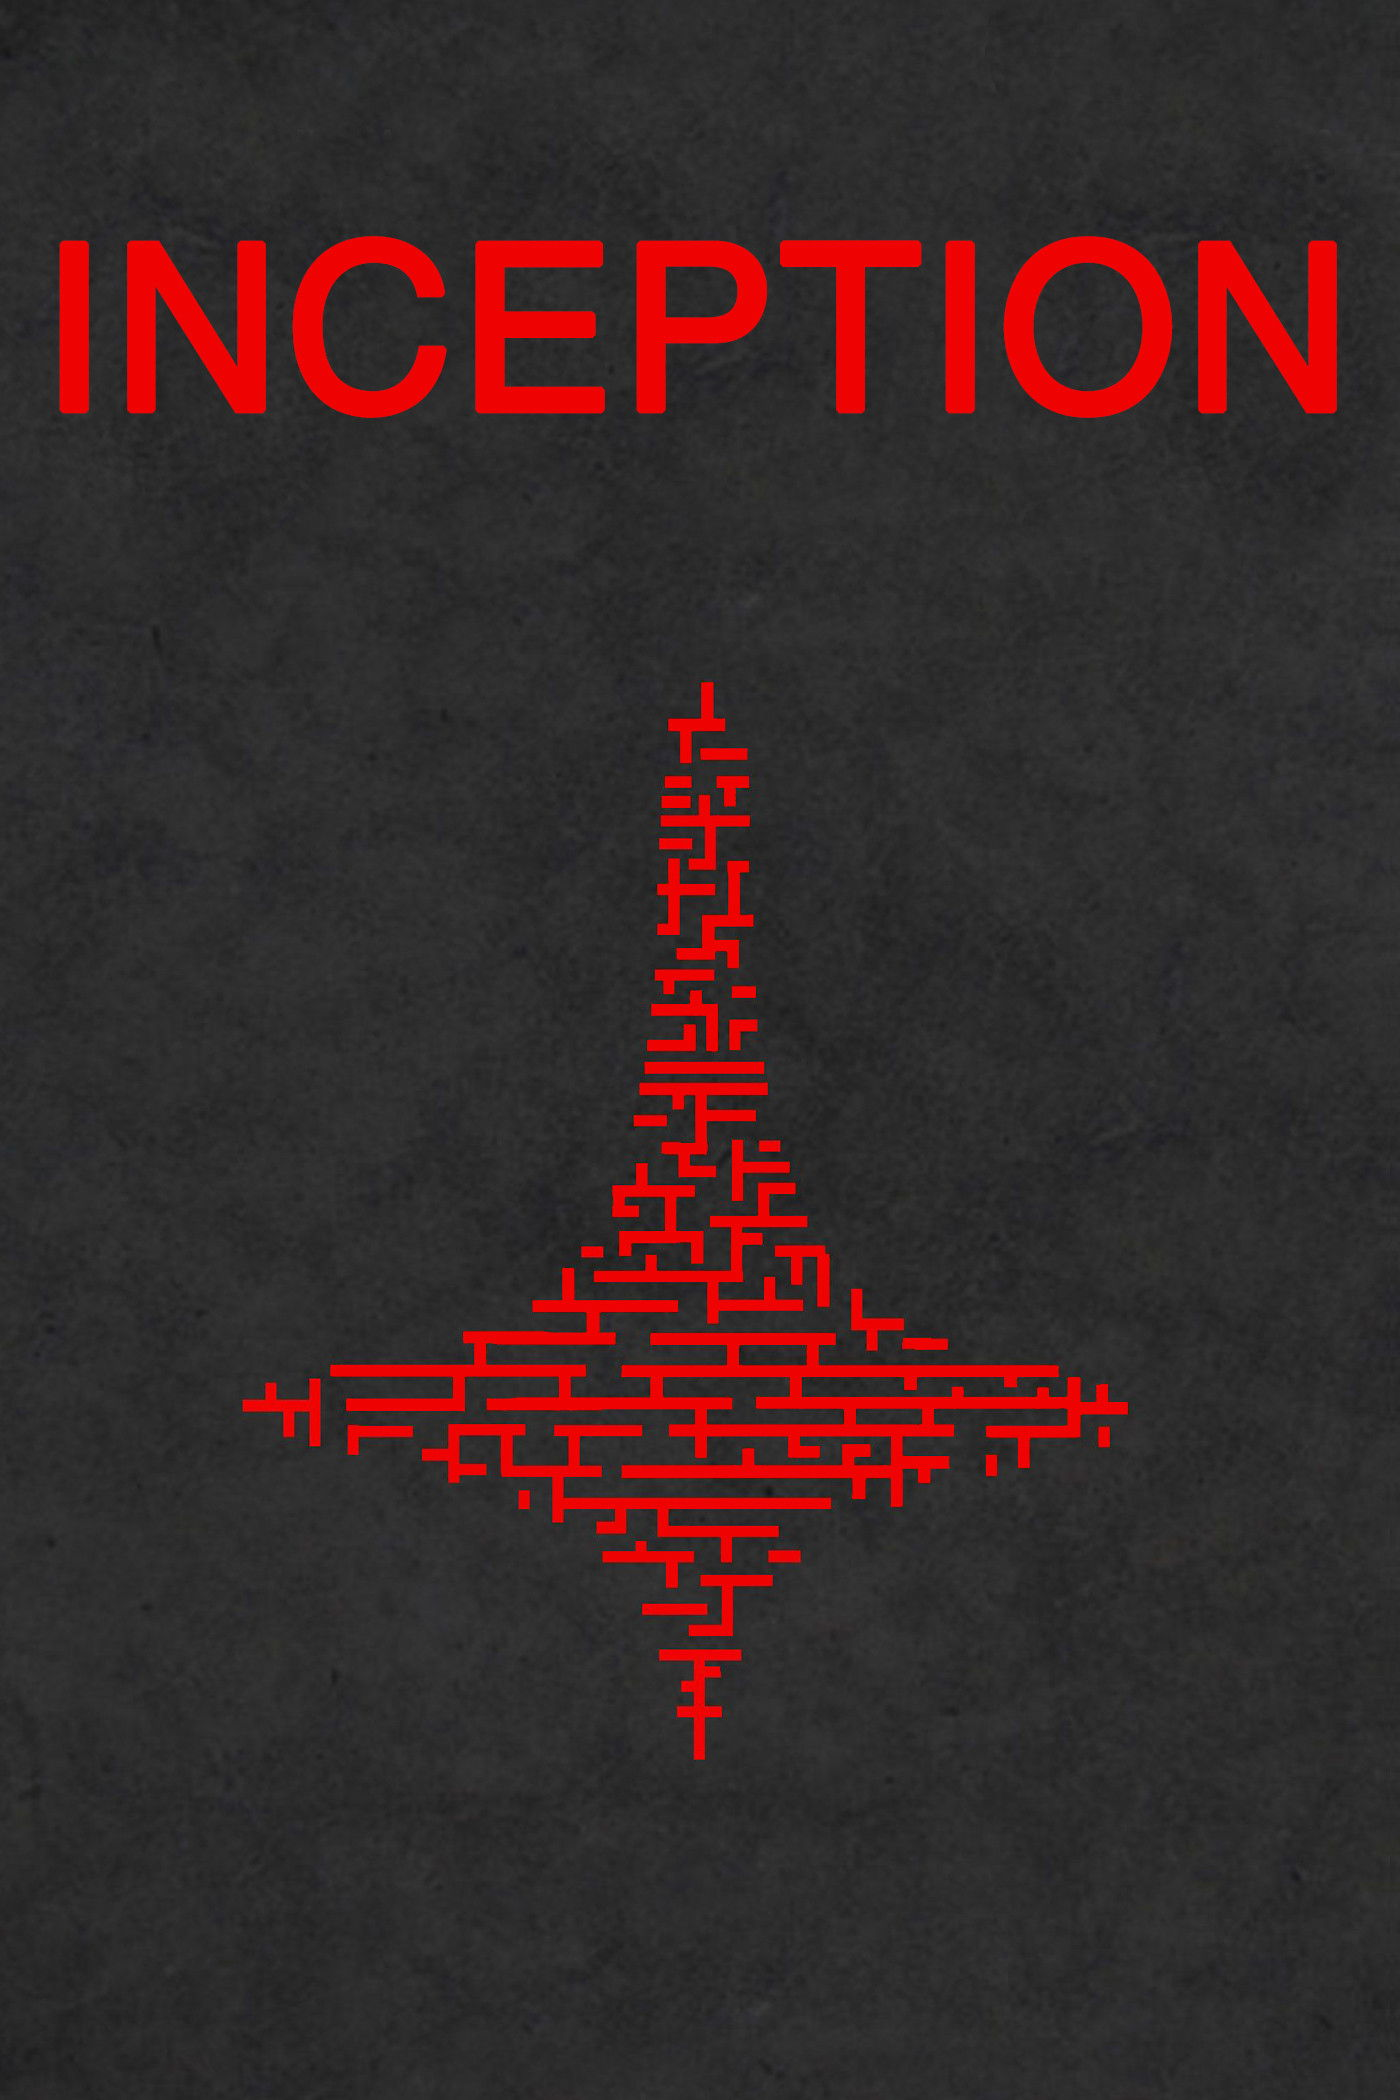

In [5]:
# Finalize the selection and copy to primary poster
PICK = pick_input.value

PRIMARY_DIR = OUTPUT_DIR / "primary"
PRIMARY_DIR.mkdir(parents=True, exist_ok=True)

chosen_file = poster_files[PICK - 1]
assert chosen_file.exists(), f"Poster file not found: {chosen_file}"

dest = PRIMARY_DIR / f"{safe_title}{chosen_file.suffix}"
shutil.copy2(chosen_file, dest)

print(f"Selected poster #{PICK}: {chosen_file.name}")
print(f"Primary poster saved to: {dest}")

from IPython.display import Image
Image(filename=str(dest), width=300)

## Feature Extraction

Run the feature extraction pipeline from FeatureIdentifier on the selected poster.

In [ ]:
# from src.feature_extraction import initialize_feature_models, extract_poster_nodes

# status = initialize_feature_models(verbose=True)

In [ ]:
# import json
# import numpy as np

# nodes = extract_poster_nodes(str(dest))

# # Pretty-print (summarize clip embedding for readability)
# nodes_print = dict(nodes)
# if isinstance(nodes_print.get("clip_embedding"), np.ndarray):
#     emb = nodes_print["clip_embedding"]
#     nodes_print["clip_embedding"] = {
#         "dim": int(emb.shape[0]),
#         "l2_norm": float(np.linalg.norm(emb)),
#         "preview": emb[:8].round(4).tolist(),
#     }

# print(json.dumps(nodes_print, indent=2))